## Finance Fraud Detection

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AIML Dataset.csv")

In [10]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [12]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [13]:
df["isFraud"].value_counts()

,count
isFraud,
0,6354407
1,8213


In [14]:
df["isFlaggedFraud"].value_counts()

,count
isFlaggedFraud,
0,6362604
1,16


In [15]:
df.isnull().sum().sum()

np.int64(0)

In [16]:
df.shape

(6362620, 11)

In [17]:
8## fraud data %
round((df["isFraud"].value_counts()[1] / df.shape[0]) * 100, 2)


np.float64(0.13)

### Visualizing with the transaction types

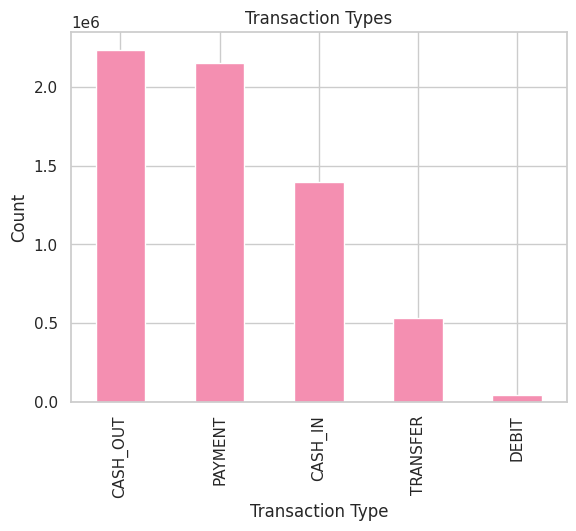

In [18]:
df["type"].value_counts().plot(kind = "bar", title = "Transaction Types", color = "#F48FB1")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

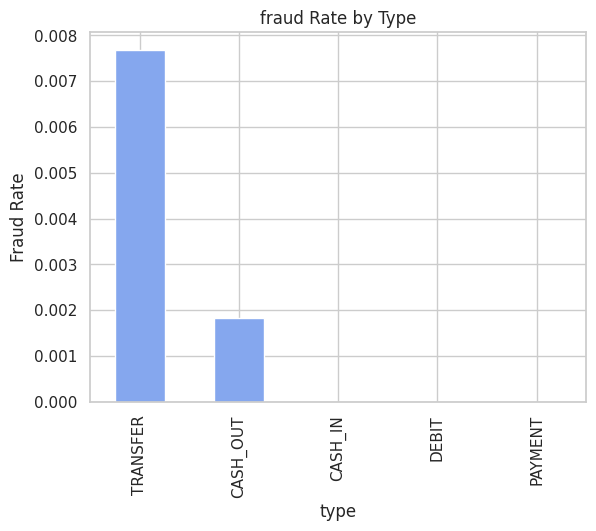

In [19]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending = False)
fraud_by_type.plot(kind = "bar", title = "fraud Rate by Type", color = "#85A7EE")
plt.ylabel("Fraud Rate")
plt.show()

#### Amount Statistics

In [20]:
df["amount"].describe().astype(int)

,amount
count,6362620
mean,179861
std,603858
min,0
25%,13389
50%,74871
75%,208721
max,92445516


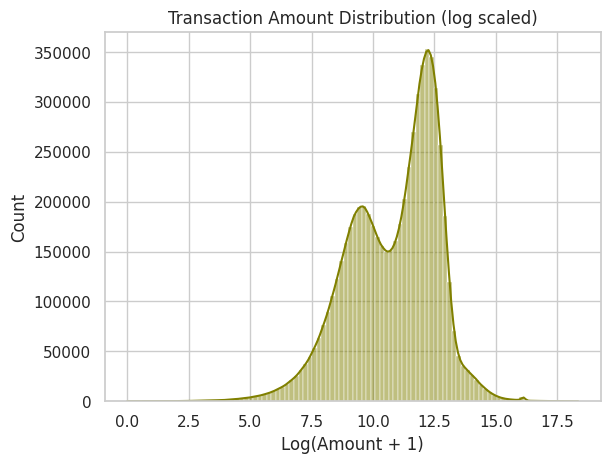

In [21]:
sns.histplot(np.log1p(df["amount"]), bins = 100, kde = True, color = "olive")
plt.title("Transaction Amount Distribution (log scaled)")
plt.xlabel("Log(Amount + 1)")
plt.show()

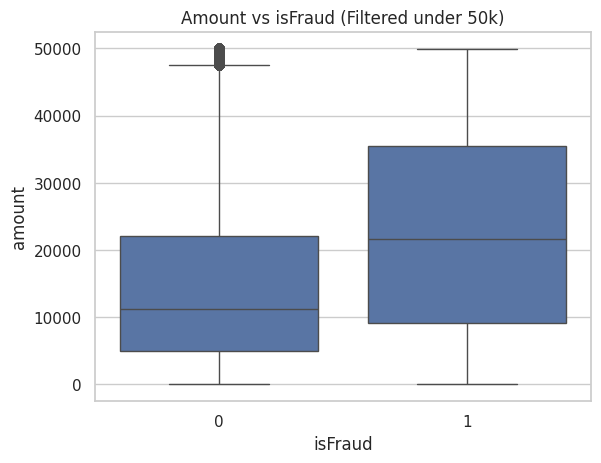

In [22]:
sns.boxplot(data = df[df["amount"] < 50000], x = "isFraud", y = "amount")
plt.title("Amount vs isFraud (Filtered under 50k)")
plt.show()

In [23]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [24]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]


In [25]:
(df["balanceDiffOrig"] < 0).sum()

np.int64(1399253)

In [26]:
(df["balanceDiffDest"] < 0).sum()

np.int64(1238864)

In [27]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


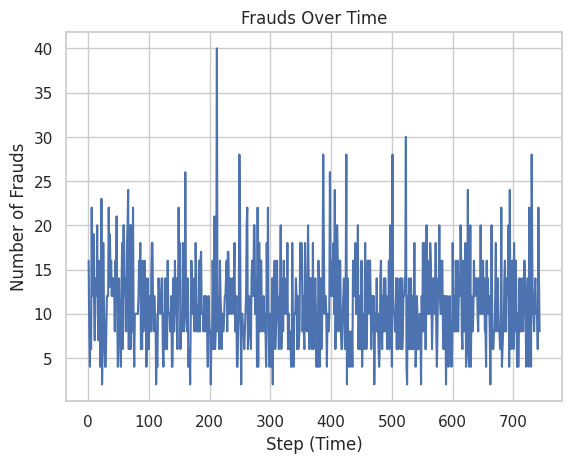

In [28]:
frauds_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values, label = "Frauds per step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

In [29]:
df.drop(columns = "step", inplace = True)

In [30]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [31]:
top_senders = df["nameOrig"].value_counts().head(10)

In [32]:
top_senders

,count
nameOrig,
C1530544995,3
C545315117,3
C724452879,3
C1784010646,3
C1677795071,3
C1462946854,3
C1065307291,3
C1999539787,3
C2098525306,3


In [33]:
top_receivers = df["nameDest"].value_counts().head(10)

In [34]:
top_receivers

,count
nameDest,
C1286084959,113
C985934102,109
C665576141,105
C2083562754,102
C248609774,101
C1590550415,101
C1789550256,99
C451111351,99
C1360767589,98


In [35]:
fraud_users = df[df["isFraud"] == 1]["nameOrig"].value_counts().head(10)

In [36]:
fraud_users

,count
nameOrig,
C1280323807,1
C1305486145,1
C840083671,1
C1420196421,1
C2101527076,1
C1039979813,1
C2089752665,1
C1614818636,1
C40604503,1


In [37]:
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]

In [38]:
fraud_types["type"].value_counts()

,count
type,
CASH_OUT,2237500
TRANSFER,532909


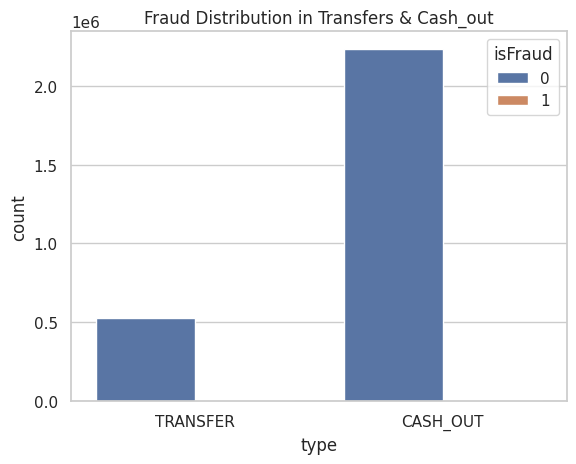

In [39]:
sns.countplot(data = fraud_types, x = "type", hue = "isFraud")
plt.title("Fraud Distribution in Transfers & Cash_out")
plt.show()

In [40]:
corr = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()

In [41]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


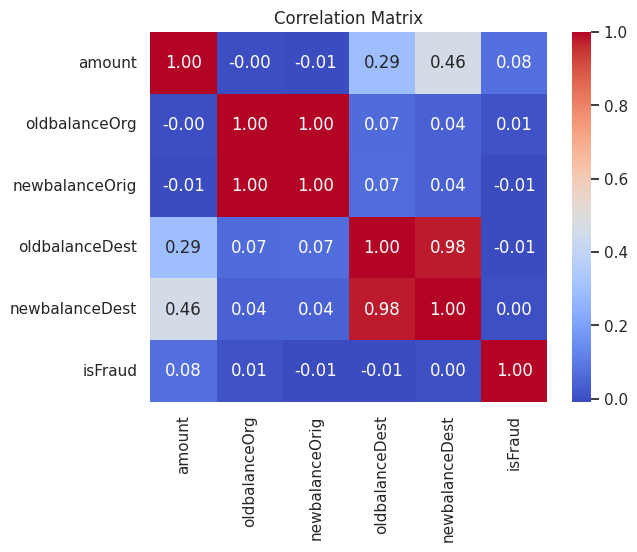

In [42]:
sns.heatmap(corr, annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Matrix")
plt.show()

In [43]:
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(["TRANSFER", "CASH_OUT"]))
]

In [44]:
len(zero_after_transfer)

1188074

In [45]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [46]:
df["isFraud"].value_counts()

,count
isFraud,
0,6354407
1,8213


## Feature Selection

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix



In [48]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [49]:
df_model = df.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis = 1)

In [50]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [51]:
categorical = ["type"]
numeric = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

In [52]:
y = df_model["isFraud"]
X = df_model.drop("isFraud",axis = 1)

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y)

In [54]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop = "first"), categorical),
    ],
    remainder = "drop"
)

In [55]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight = "balanced", max_iter = 1000))
])

In [56]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [57]:
y_pred = pipeline.predict(X_test)

In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.93      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [59]:
confusion_matrix(y_test, y_pred)

array([[1804355,  101967],
       [    165,    2299]])

In [60]:
pipeline.score(X_test, y_test) * 100

94.64937400001887

In [61]:
import joblib
joblib.dump(pipeline, "fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']

# Linear SVC

Best Threshold: 3.3252
Best F1 Score: 0.5572

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.81      0.42      0.56      1643

    accuracy                           1.00   1272524
   macro avg       0.91      0.71      0.78   1272524
weighted avg       1.00      1.00      1.00   1272524



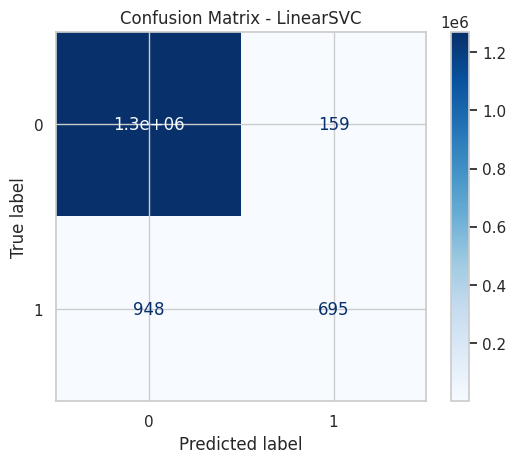

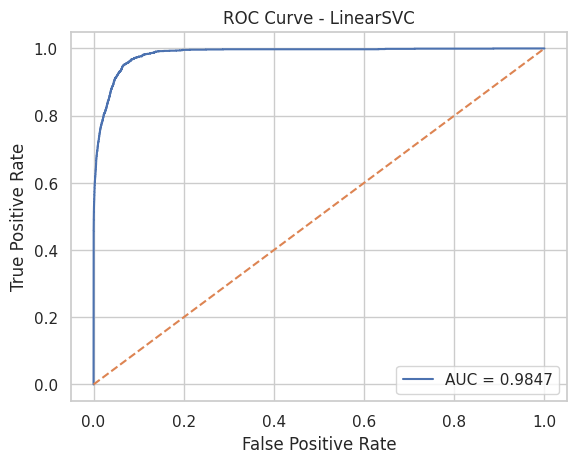

In [68]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, roc_curve, auc
from sklearn.svm import LinearSVC
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# 1. PREPARE DATA (FULL DATASET)
X_svm = X.copy()
y_svm = y.copy()

categorical_cols = ['type'] if 'type' in X_svm.columns else []
numerical_cols = [col for col in X_svm.columns if col not in categorical_cols]

# 2. MEMORY OPTIMIZATION
for col in X_svm.select_dtypes(include=['float64']).columns:
    X_svm[col] = X_svm[col].astype('float32')

for col in X_svm.select_dtypes(include=['int64']).columns:
    X_svm[col] = X_svm[col].astype('int32')

# 3. SPARSE PREPROCESSING (CRITICAL)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ],
    sparse_threshold=1.0   # 🔥 FORCE SPARSE OUTPUT
)

# 4. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_svm, y_svm, test_size=0.2, random_state=42, stratify=y_svm
)

# 5. CLASS IMBALANCE
fraud_ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 6. PIPELINE (NO SCALING → avoids dense conversion)
model = Pipeline([
    ('preprocessor', preprocessor),
    ('svm', LinearSVC(
        class_weight={0:1, 1:fraud_ratio * 0.7},
        max_iter=3000,
        random_state=42
    ))
])

# 7. TRAIN
model.fit(X_train, y_train)

# 8. DECISION SCORES
y_scores = model.decision_function(X_test)

# 9. THRESHOLD TUNING (F1)
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 Score: {f1_scores[best_idx]:.4f}")

# 10. FINAL PREDICTIONS
y_pred = (y_scores > best_threshold).astype(int)

# 11. EVALUATION
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    # normalize='true',
    cmap='Blues'
)
plt.title("Confusion Matrix - LinearSVC")
plt.show()

# 13. ROC CURVE
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LinearSVC")
plt.legend()
plt.show()

# LGBM

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	train's auc: 0.994617	valid's auc: 0.991602
              precision    recall  f1-score   support

           0       1.00      0.97      0.98   1270881
           1       0.04      1.00      0.07      1643

    accuracy                           0.97   1272524
   macro avg       0.52      0.98      0.53   1272524
weighted avg       1.00      0.97      0.98   1272524



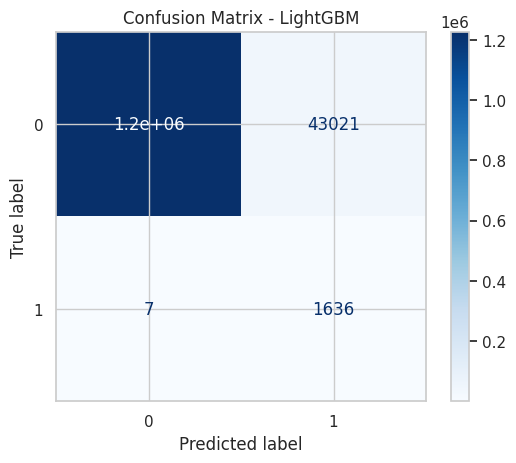

In [69]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Memory Optimization: Convert types
# Assuming 'type' is your categorical column and 'isFraud' is your target
X = df_model.drop('isFraud', axis=1)
y = df_model['isFraud']

# Convert 'type' to category for LightGBM's native handling (saves massive RAM)
if 'type' in X.columns:
    X['type'] = X['type'].astype('category')

# Downcast floats to float32
for col in X.select_dtypes(include=['float64']).columns:
    X[col] = X[col].astype('float32')

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. LightGBM Dataset with Categorical Support
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=['type'], free_raw_data=False)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data, free_raw_data=False)

# 4. Optimized Hyperparameters for Fraud (Imbalanced Data)
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'is_unbalance': True,  # CRITICAL: Automatically weights the minority (fraud) class
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'n_jobs': -1,           # Use all CPU cores
    'verbosity': -1
}

# 5. Train with Early Stopping
model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, test_data],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 6. Predictions & Evaluation
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# 7. Visualization
print(classification_report(y_test, y_pred))

# cm = confusion_matrix(y_test, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
# disp.plot(cmap='Blues')
# plt.title('LightGBM Fraud Detection Confusion Matrix')
# plt.show()


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    # normalize='true',
    cmap='Blues'
)
plt.title("Confusion Matrix - LightGBM")
plt.show()

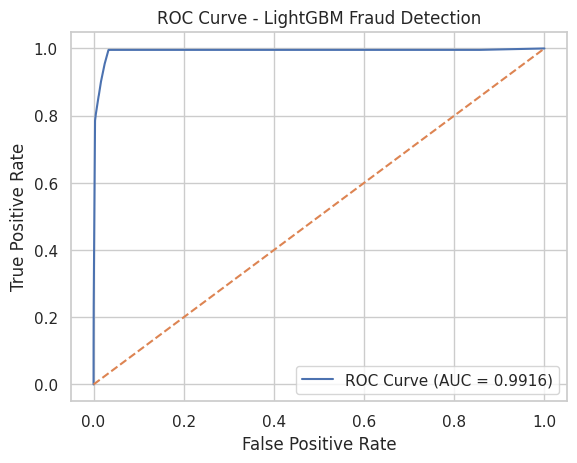

In [70]:
from sklearn.metrics import roc_curve, auc

# 8. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # Random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM Fraud Detection')
plt.legend()
plt.show()

In [66]:
# %pip install xgboost

# XGBoost

In [71]:
import xgboost as xgb
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve
from sklearn.pipeline import Pipeline

# 1. PREPARE DATA
X_xgb = X.copy()
y_xgb = y.copy()

if 'type' in X_xgb.columns:
    X_xgb['type'] = X_xgb['type'].astype('category')

X_train, X_test, y_train, y_test = train_test_split(
    X_xgb, y_xgb, test_size=0.2, random_state=42, stratify=y_xgb
)

# 2. CLASS IMBALANCE
fraud_ratio = (y_train == 0).sum() / (y_train == 1).sum()
scale_weight = fraud_ratio * 0.7

# 3. XGBOOST MODEL
xgb_model = xgb.XGBClassifier(
    tree_method='hist',
    device='cpu',
    enable_categorical=True,
    scale_pos_weight=scale_weight,

    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=5,
    gamma=1,
    subsample=0.7,
    colsample_bytree=0.7,

    eval_metric='auc',
    n_jobs=-1,
    random_state=42
)

# 4. PIPELINE (WITH PREPROCESSOR)
pipeline = Pipeline([
    ("prep", preprocessor),   # your existing preprocessor
    ("clf", xgb_model)
])

# 5. TRAIN
pipeline.fit(X_train, y_train)

# 6. PROBABILITY PREDICTION
y_pred_prob = pipeline.predict_proba(X_test)[:, 1]

# 7. BEST THRESHOLD (F1)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 Score: {f1_scores[best_idx]:.4f}")

# 8. FINAL PREDICTIONS
y_pred = (y_pred_prob > best_threshold).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 9. SAVE PIPELINE + THRESHOLD
joblib.dump({
    "model": pipeline,
    "threshold": best_threshold
}, "xgboost_fraud_pipeline.pkl")

Best Threshold: 0.9956
Best F1 Score: 0.8474

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.97      0.75      0.85      1643

    accuracy                           1.00   1272524
   macro avg       0.99      0.87      0.92   1272524
weighted avg       1.00      1.00      1.00   1272524



['xgboost_fraud_pipeline.pkl']

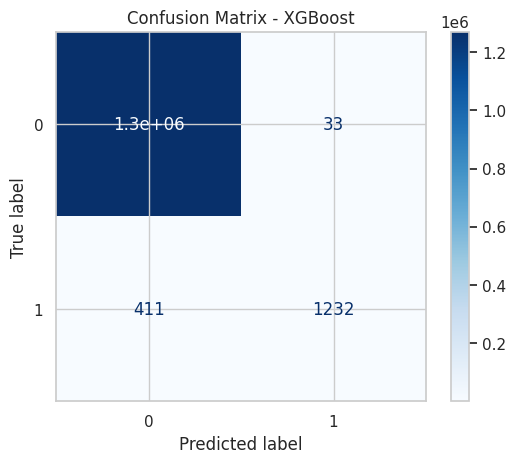

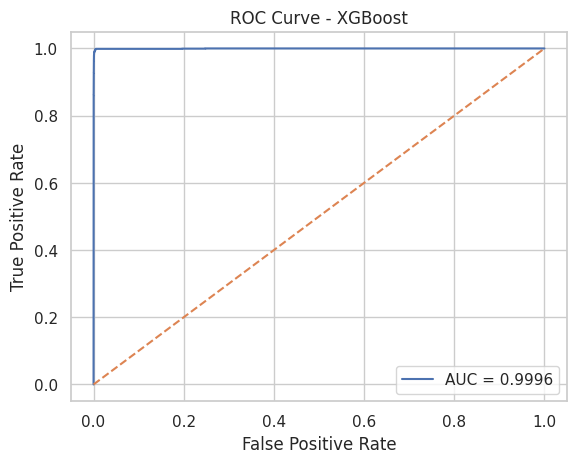

In [72]:
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    # normalize='true',
    cmap='Blues'
)
plt.title("Confusion Matrix - XGBoost")
plt.show()


# ROC Curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.show()